NBA Project Ready
Everything imported Successfully!
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PLAYER_NAME        569 non-null    str    
 1   TEAM_ABBREVIATION  569 non-null    str    
 2   AGE                569 non-null    float64
 3   GP                 569 non-null    int64  
 4   PTS                569 non-null    float64
 5   REB                569 non-null    float64
 6   AST                569 non-null    float64
 7   FG_PCT             569 non-null    float64
 8   FG3_PCT            569 non-null    float64
 9   FT_PCT             569 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 44.6 KB


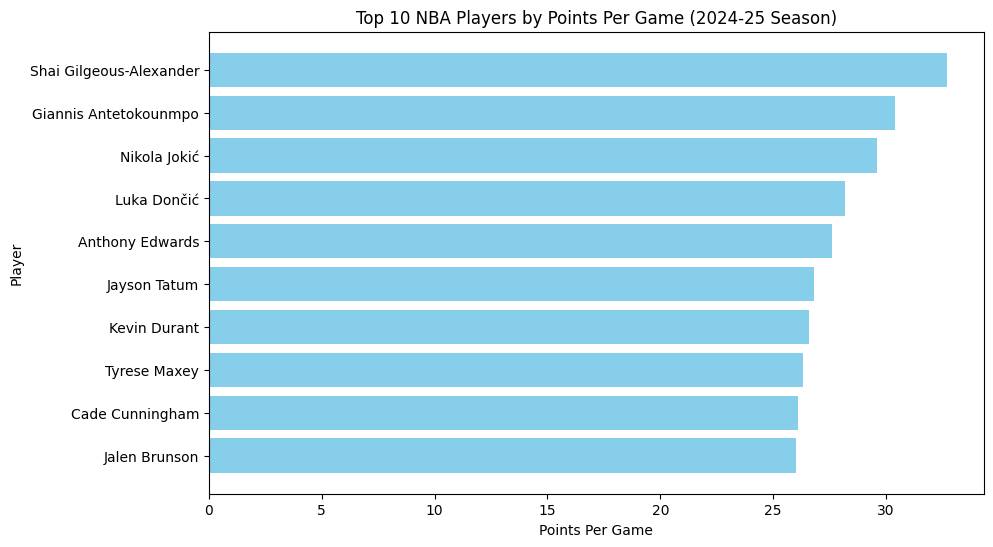

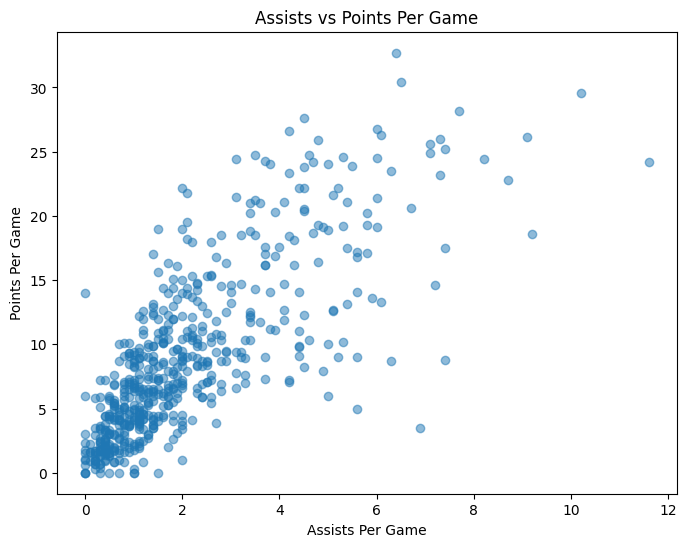

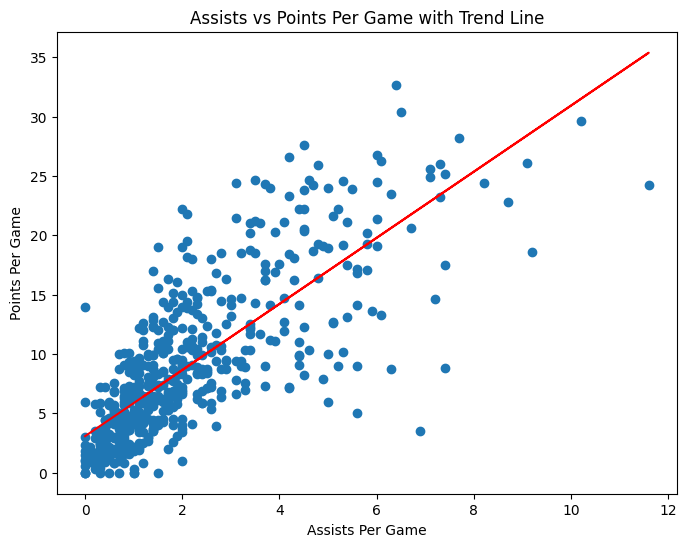

0.7013144578261583


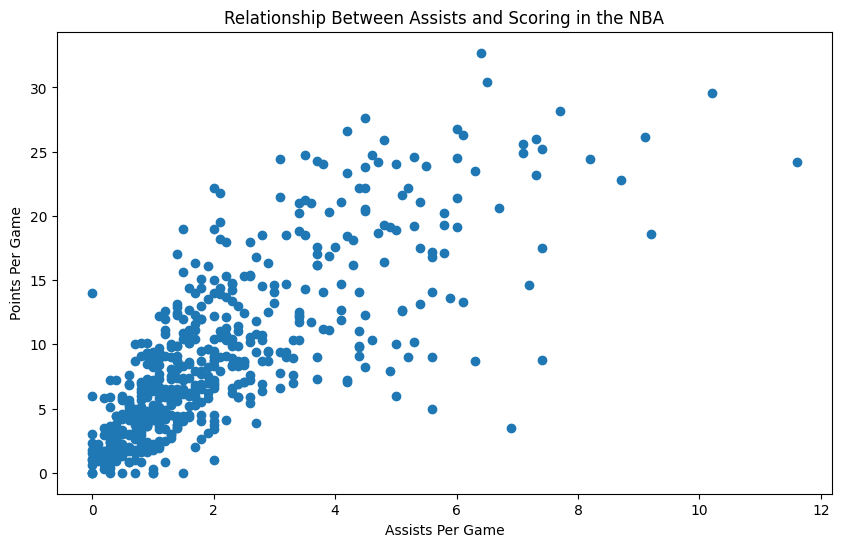

0.5950589676993416


In [33]:
print("NBA Project Ready")
import pandas as pd 
import matplotlib.pyplot as plt 
from nba_api.stats.endpoints import leaguedashplayerstats
print("Everything imported Successfully!")

stats= leaguedashplayerstats.LeagueDashPlayerStats(
    season='2024-25',
    per_mode_detailed='PerGame'

)

df= stats.get_data_frames()[0]
df.head()
df.shape 
df.columns.tolist()
df=df[['PLAYER_NAME',
'TEAM_ABBREVIATION',
'AGE',
'GP',
'PTS',
'REB',
'AST',
'FG_PCT',
'FG3_PCT',
'FT_PCT']]

df.head()
df.info()
top10 = df.sort_values(by='PTS', ascending=False).head(10)


import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(top10['PLAYER_NAME'], top10['PTS'], color='skyblue')

plt.xlabel('Points Per Game')
plt.ylabel('Player')
plt.title('Top 10 NBA Players by Points Per Game (2024-25 Season)')

plt.gca().invert_yaxis()
plt.show()

correlations = df[[
    'PTS',
    'REB',
    'AST',
    'FG_PCT',
    'FG3_PCT',
    'FT_PCT'
]].corr()

correlations['PTS'].sort_values(ascending=False)


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['AST'], df['PTS'], alpha=0.5)

plt.xlabel('Assists Per Game')
plt.ylabel('Points Per Game')
plt.title('Assists vs Points Per Game')

plt.show()

import numpy as np
x = df['AST']
y = df['PTS']

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))

plt.scatter(x, y,)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Assists Per Game')
plt.ylabel('Points Per Game')
plt.title('Assists vs Points Per Game with Trend Line')

plt.show()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['AST', 'REB', 'FG_PCT', 'FG3_PCT', 'FT_PCT']]
y = df['PTS']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print(score)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coefficients.sort_values(by='Coefficient', ascending=False)


plt.figure(figsize=(10,6))

plt.scatter(df['AST'], df['PTS'])

plt.xlabel('Assists Per Game')
plt.ylabel('Points Per Game')
plt.title('Relationship Between Assists and Scoring in the NBA')

plt.savefig('assists_vs_points.png')

plt.show()

from sklearn.linear_model import LinearRegression

X_simple = df[['AST']]
y_simple = df['PTS']

simple_model = LinearRegression()
simple_model.fit(X_simple, y)

print(simple_model.score(X_simple, y))





NBA Player Scoring Analysis

Goal:
Determine which player statistics are most associated with scoring.

Tools:
- Python
- Pandas
- Matplotlib
- Scikit-learn

Methods:
- Data cleaning
- Correlation analysis
- Data visualization
- Linear regression

Results:
- Assists showed the strongest correlation with scoring (r = 0.771).
- Regression model achieved R² = 0.701.
- Offensive involvement was a strong predictor of scoring.